In this notebook, we will be creating a CNN (Convolutional Neural Network) based classifier for the classification of CIFAR-10 dataset.

**About the dataset**

CIFAR-10 dataset is a subset of CIFAR-100 having 80 million images of 100 different objects. CIFAR-10 takes 60,000 images for 10 classes from the original dataset in which 50,000 images are for training and 10,000 images are for testing.

The classes in the dataset are -
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

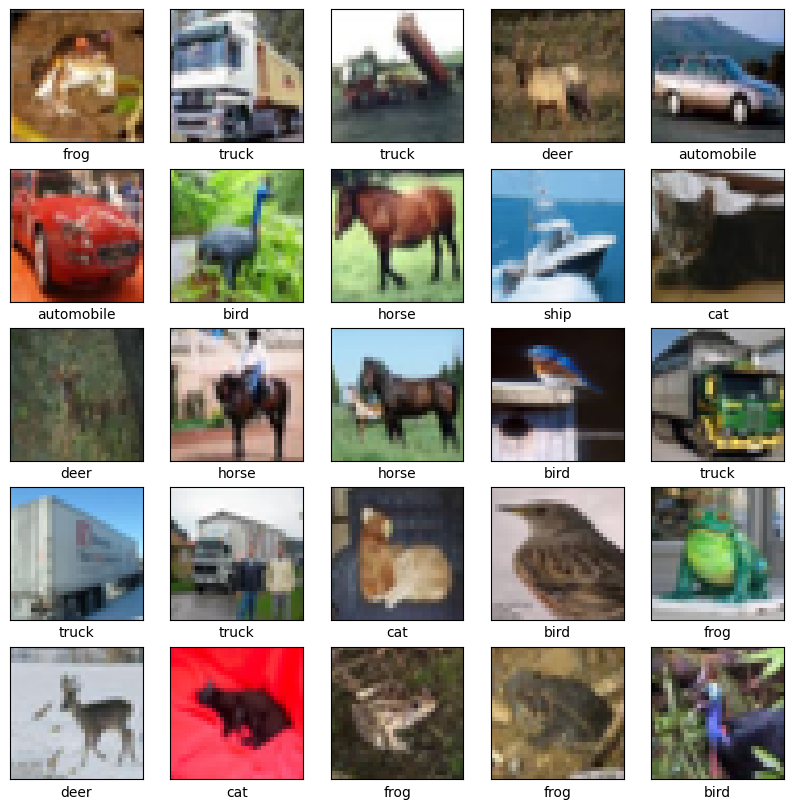

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Creating a CNN model**

We are going to create a CNN based classification model using *keras* module.

In [ ]:
model = models.Sequential()

# This new Input layer fixes the red UserWarning in your screenshot!
model.add(layers.Input(shape=(32, 32, 3)))

# Layer 1
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Layer 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Layer 3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Layer 4 (Your new addition!)
# We increase the filters to 128 to help it learn more complex patterns
model.add(layers.Conv2D(128, (3, 3), activation='relu'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,176 (508.50 KB)

 Trainable params: 130,176 (508.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,658 (639.29 KB)

 Trainable params: 163,658 (639.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='sgd',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - accuracy: 0.2146 - loss: 2.1211 - val_accuracy: 0.3022 - val_loss: 1.9022
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.3626 - loss: 1.7525 - val_accuracy: 0.3959 - val_loss: 1.7073
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.4465 - loss: 1.5245 - val_accuracy: 0.4799 - val_loss: 1.4242
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.5003 - loss: 1.3933 - val_accuracy: 0.4849 - val_loss: 1.4119
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.5351 - loss: 1.3023 - val_accuracy: 0.5343 - val_loss: 1.2880
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.5662 - loss: 1.2241 - val_accuracy: 0.5541 - val_loss: 1.2354
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.5917 - loss: 1.1574 - val_accuracy: 0.5850 - val_loss: 1.1536
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.6147 -

313/313 - 4s - 12ms/step - accuracy: 0.6137 - loss: 1.1142


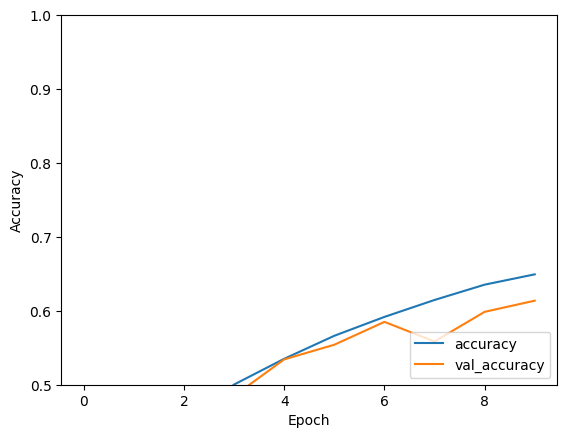

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
print(test_acc)

0.6136999726295471


In [ ]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.6226 - loss: 1.0643 - val_accuracy: 0.6385 - val_loss: 1.0305
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.6854 - loss: 0.8973 - val_accuracy: 0.6881 - val_loss: 0.8939
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - accuracy: 0.7272 - loss: 0.7817 - val_accuracy: 0.6752 - val_loss: 0.9472
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7554 - loss: 0.6913 - val_accuracy: 0.6959 - val_loss: 0.8894
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 50ms/step - accuracy: 0.7851 - loss: 0.6105 - val_accuracy: 0.7081 - val_loss: 0.8736
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 46ms/step - accuracy: 0.8079 - loss: 0.5439 - val_accuracy: 0.7221 - val_loss: 0.8731
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.8307 - loss: 0.4776 - val_accuracy: 0.7031 - val_loss: 0.9667
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.8490 -

313/313 - 5s - 16ms/step - accuracy: 0.7086 - loss: 1.0962


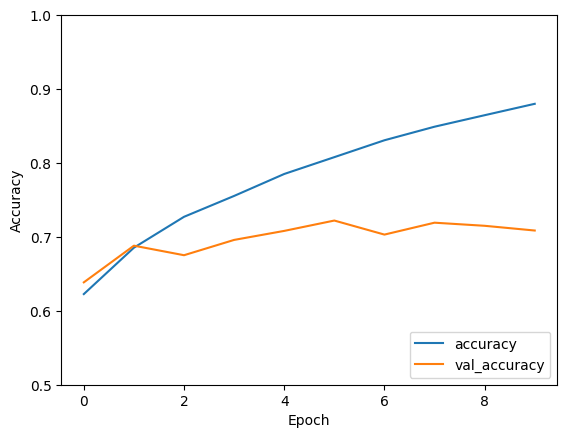

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
print(test_acc)

0.7085999846458435


In [ ]:
# save model
model.save('final_model.keras') #previously saved as 'final_model.h5", a legacy

--- Starting Predictions ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step

File: airplane.jpg --> AI Prediction: airplane (100.00%)


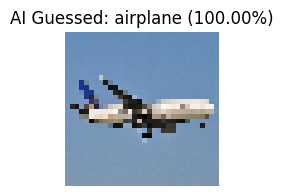

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

File: bird.jpg --> AI Prediction: bird (99.35%)


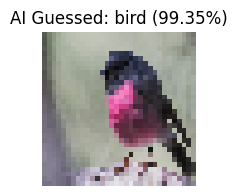

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

File: ship.jpg --> AI Prediction: ship (100.00%)


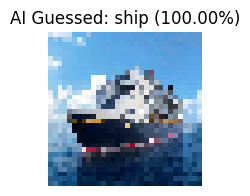

In [ ]:
# make a prediction for new images
import tensorflow as tf
from tensorflow.keras import preprocessing
from tensorflow.keras import models
import numpy as np
import matplotlib.pyplot as plt # We added this to draw the images!

# Re-define class names just to be safe
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def load_image(filename):
	# load the image
	img = preprocessing.image.load_img(filename, target_size=(32, 32))
	# convert to array
	img = preprocessing.image.img_to_array(img)
	# reshape into a single sample with 3 channels
	img = img.reshape(1, 32, 32, 3)
	# prepare pixel data
	img = img.astype('float32')
	img = img / 255.0
	return img

def run_example():
	# Load the model
	model = models.load_model('final_model.keras')

	# Your exact file names
	my_images = ['airplane.jpg', 'bird.jpg', 'ship.jpg']

	print("--- Starting Predictions ---")
	for img_name in my_images:
		try:
			img = load_image(img_name)
			pred_list = model.predict(img)

			# --- NEW PERCENTAGE MATH ---
			# 1. Convert the raw output numbers into probability percentages
			probabilities = tf.nn.softmax(pred_list[0])

			# 2. Find the index of the highest percentage
			result = np.argmax(probabilities)

			# 3. Get the actual class name and the highest percentage value (multiplied by 100)
			prediction = class_names[result]
			confidence = probabilities[result] * 100
			# ---------------------------

			# Updated print statement to show the percentage rounded to 2 decimal places
			print(f"\nFile: {img_name} --> AI Prediction: {prediction} ({confidence:.2f}%)")

			# Draw the 32x32 image on the screen
			plt.figure(figsize=(2,2))
			plt.imshow(img[0])
			# Updated title to show the percentage on the graph
			plt.title(f"AI Guessed: {prediction} ({confidence:.2f}%)")
			plt.axis('off')
			plt.show()

		except FileNotFoundError:
			print(f"Error: Could not find '{img_name}'. Make sure you uploaded it to Colab!")

# run the example
run_example()